# Stages 2 & 3: dimension ladder, box-limit PINN, and the frontier

Companion to `stage1_pinn_train_and_analysis.ipynb`, completing the arc:

- **Stage 2** — frozen vegas kept, per-option **box limits** replace the
  aggregate-vega band.  The 2D reduction dies (demonstrated as a negative
  control in the test suite: 5,417 EUR value spread at equal
  $\mathcal{V}^\pi$).  The exact q-lattice is the reference: we run the
  **dimension ladder $N=3/4/5$** and validate a box-admissibility PINN
  against the lattice on *every admissible state* at $N=3$.
- **Stage 3** — both assumptions dropped: state-dependent vegas
  $\mathcal{V}_i(t,S,\nu)$ (including a tight call spread whose vega
  **flips sign** in $S$ — the barrier-like feature), $S$ back in the state,
  box limits.  No exact reference at any $N$: validation is (i) the
  frozen-Greeks **regression** (the $S$-featured machinery must reproduce
  stage-1 answers and *not invent* $S$-dependence), (ii) residual
  certificates, (iii) the **Dynkin closure**
  $\ \mathbb{E}[\text{reward}] = v_\theta(0) + \mathbb{E}\int R\,dt$,
  pre-validated at stage 1 (`tests/test_corrector.py`).

Re-entrant: heavy phases load from `checkpoints/` and top up; profiles
auto-switch to the H200 budget on CUDA.

In [1]:
import os, sys, time, pickle
from pathlib import Path
from functools import partial
from dataclasses import replace

import jax, jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists():
    assert ROOT != ROOT.parent, 'run from inside the optmm repo'
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
CKPT = ROOT / 'checkpoints'; CKPT.mkdir(exist_ok=True)
import optmm  # noqa: F401

ON_GPU = any(d.platform == 'gpu' for d in jax.devices())
PROFILE = dict(
    name='h200' if ON_GPU else 'cpu-smoke',
    hidden=(128, 128, 128) if ON_GPU else (64, 64, 64),
    fresh_steps=60_000 if ON_GPU else 6_000,
    topup_steps=20_000 if ON_GPU else 300,
    batch=4096 if ON_GPU else 256,
    lr=2e-3,
    ladder_cfg={3: dict(idx=[2, 7, 8], nbar=[5, 4, 4], n_nu=21, nt=200),
                4: dict(idx=[2, 7, 8, 12], nbar=[3, 3, 3, 2], n_nu=13, nt=120),
                5: dict(idx=[2, 7, 8, 12, 17], nbar=[2, 2, 2, 2, 2],
                        n_nu=9, nt=100)},
    closure_paths=4000 if ON_GPU else 800,
)
print('devices:', jax.devices())
print('profile:', PROFILE['name'])

devices: [CpuDevice(id=0)]
profile: cpu-smoke


## 1. Stage 2 — the dimension ladder ($N=3/4/5$, exact lattice)

Box limits, ATM-ish sub-books of the BBG universe.  The lattice is exact in
inventory (jumps are exact gathers) and RK4-exact in time (step-halving
column).  The table is the honest cost curve of the exact method: the only
curse here is **cardinality** — states grow as $\prod_i(2\bar n_i+1)$,
with no $\varepsilon$-resolution curse (discrete atoms give lattice
closure).  This is what a PINN must beat to be justified, and at these $N$
it plainly is not — the PINN's case begins where this table's growth makes
the lattice unaffordable.

 N  states M nu pts  solve (s)  step-halving   v(0,nu0,0)
 3     1,573     21       23.5      8.30e-04       39,872
 4     5,103     13       37.3      6.65e-03       49,311
 5    16,807      9       82.3      9.75e-03       54,872


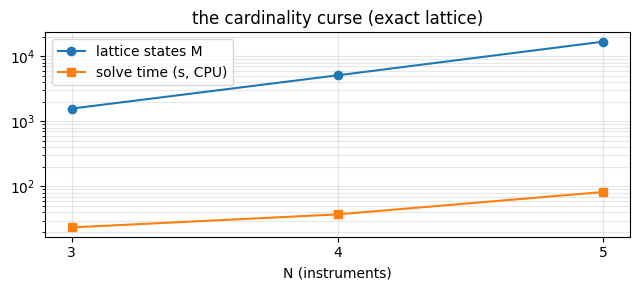

In [2]:
from optmm.core.risk import BBG_MARKET, penalty_coef
from optmm.core.state import Box, Slab
from optmm.instruments.book import build_bbg_book, FrozenBook
from optmm.solvers.lattice import solve_lattice, subbook
from optmm.solvers.reduced2d import Channels, _bc

book = build_bbg_book(BBG_MARKET)
GAMMA, T1 = 1e-3, 0.0012
ladder = {}
for N, cfg in PROFILE['ladder_cfg'].items():
    f = CKPT / f'ladder_N{N}.npz'
    if f.exists():
        ladder[N] = dict(np.load(f))
    else:
        sb = subbook(book, cfg['idx'])
        t0 = time.time()
        lat = solve_lattice(sb, BBG_MARKET, GAMMA, Box(np.array(cfg['nbar'])),
                            T1, nt=cfg['nt'], n_nu=cfg['n_nu'])
        v0 = np.asarray(lat.v0)
        lat_h = solve_lattice(sb, BBG_MARKET, GAMMA,
                              Box(np.array(cfg['nbar'])), T1,
                              nt=cfg['nt'] // 2, n_nu=cfg['n_nu'])
        ladder[N] = dict(v0=v0, n_pts=lat.n_pts, Vpi=np.asarray(lat.Vpi),
                         quotes=np.asarray(lat.quotes()),
                         t_solve=time.time() - t0,
                         conv=float(np.max(np.abs(np.asarray(lat_h.v0) - v0))),
                         nbar=np.array(cfg['nbar']), n_nu=cfg['n_nu'],
                         nt=cfg['nt'], idx=np.array(cfg['idx']),
                         v_center=v0[cfg['n_nu'] // 2,
                                     lat.idx_of([0] * N)])
        np.savez(f, **ladder[N])

print(f"{'N':>2} {'states M':>9} {'nu pts':>6} {'solve (s)':>10} "
      f"{'step-halving':>13} {'v(0,nu0,0)':>12}")
Ms, ts = [], []
for N, d in ladder.items():
    M_ = d['n_pts'].shape[0]
    Ms.append(M_); ts.append(float(d['t_solve']))
    print(f"{N:>2} {M_:>9,} {int(d['n_nu']):>6} {float(d['t_solve']):>10.1f} "
          f"{float(d['conv']):>13.2e} {float(d['v_center']):>12,.0f}")

fig, ax = plt.subplots(figsize=(6.5, 3))
ax.semilogy(list(ladder), Ms, 'o-', label='lattice states M')
ax.semilogy(list(ladder), ts, 's-', label='solve time (s, CPU)')
ax.set_xticks(list(ladder)); ax.set_xlabel('N (instruments)')
ax.set_title('the cardinality curse (exact lattice)')
ax.grid(alpha=.3, which='both'); ax.legend()
plt.tight_layout(); plt.show()

## 2. Stage-2 PINN at $N=3$: validated on *every admissible state*

The same structure-blind architecture, trained on the **box-admissibility
residual** (the only change is the post-trade indicator — the constraint
object is passed to the residual, never featurized).  Because the lattice is
exact here, the PINN error below is a true error, not a
reference-limited one.  Structure prediction: under the box the exact value
is *no longer* a function of $\mathcal{V}^\pi$ alone, and the deviation
concentrates near the box faces — both visible below.

<>:70: SyntaxWarning: invalid escape sequence '\m'
<>:70: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_474/46767850.py:70: SyntaxWarning: invalid escape sequence '\m'
  axes[2].set_title('reduction death: value is not $f(\mathcal{V}^\pi)$\n(color = face distance)')


resumed stage-2 checkpoint; topping up 300 steps


  adam     0: loss 8.3282e+12 (rms 2.886e+06)


  adam    75: loss 9.7659e+12 (rms 3.125e+06)


  adam   150: loss 6.1513e+12 (rms 2.480e+06)


  adam   225: loss 8.1044e+12 (rms 2.847e+06)


  adam   299: loss 5.2059e+12 (rms 2.282e+06)


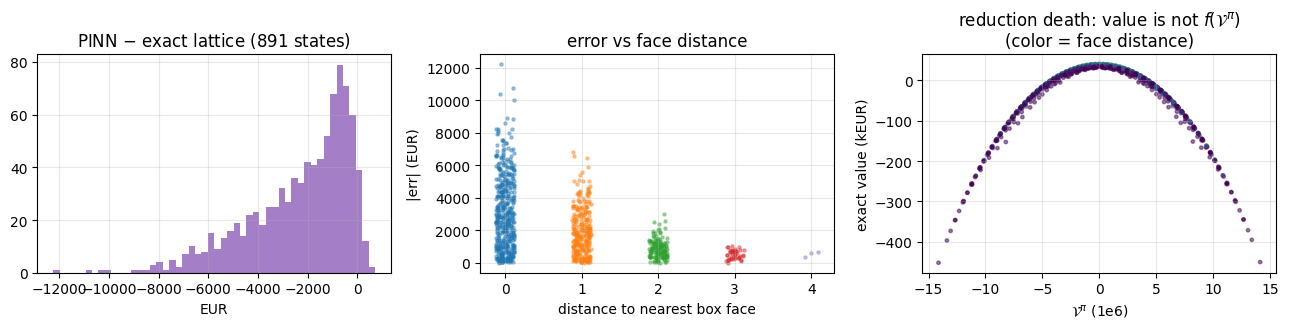

stage-2 PINN vs exact lattice: median |err| 1,726 EUR, max 12,239 (center scale 39,872)
exact-value spread at fixed Vpi (median over bins): 75,832 EUR — the reduction is genuinely dead


In [3]:
from optmm.solvers.pinn.model import PinnSpec, init_params, value
from optmm.solvers.pinn.train import make_loss, adam_train

N2 = 3
cfg2 = PROFILE['ladder_cfg'][N2]
sb2 = subbook(book, cfg2['idx'])
ch2 = Channels.from_book(sb2)
NBAR2 = np.array(cfg2['nbar']); box2 = Box(NBAR2)
spec2 = PinnSpec(T=T1, nu_lo=0.0144, nu_hi=0.0324, w=jnp.asarray(sb2.w),
                 Vbar=1e7, hidden=PROFILE['hidden'])
loss2, _ = make_loss(spec2, ch2, BBG_MARKET, GAMMA, 0.0, 1e7, adm_set=box2)
nb2 = jnp.asarray(NBAR2, jnp.float64)

def box_sampler(key, spec, batch):
    k1, k2, k3 = jax.random.split(key, 3)
    t = jax.random.uniform(k1, (batch,)) * spec.T
    pad = 0.2 * (spec.nu_hi - spec.nu_lo)
    nu = jax.random.uniform(k2, (batch,)) * (spec.nu_hi - spec.nu_lo + 2 * pad) \
        + spec.nu_lo - pad
    n = jax.random.uniform(k3, (batch, N2), minval=-1., maxval=1.) * nb2[None, :]
    return t, nu, n

ck2 = CKPT / 'pinn_stage2_smoke.pkl'
key = jax.random.PRNGKey(0)
if ck2.exists():
    with open(ck2, 'rb') as fh:
        s2 = pickle.load(fh)
    params2 = jax.tree_util.tree_map(jnp.asarray, s2['params'])
    lh2 = list(s2.get('loss_hist', []))
    steps2 = PROFILE['topup_steps']
    print(f'resumed stage-2 checkpoint; topping up {steps2} steps')
else:
    params2 = init_params(spec2, key); lh2 = []
    steps2 = PROFILE['fresh_steps']
params2, h2 = adam_train(params2, loss2, spec2, jax.random.PRNGKey(1),
                         steps=steps2, batch=PROFILE['batch'],
                         lr=PROFILE['lr'], log_every=max(steps2 // 4, 1),
                         sampler=box_sampler)
off = lh2[-1][0] + 1 if lh2 else 0
lh2 += [(off + i, l) for i, l in h2]
with open(ck2, 'wb') as fh:
    pickle.dump({'params': jax.tree_util.tree_map(np.asarray, params2),
                 'hidden': tuple(PROFILE['hidden']), 'nbar': NBAR2,
                 'loss_hist': lh2}, fh)

lad2 = ladder[N2]
n_pts2 = lad2['n_pts']; i_nu2 = int(lad2['n_nu']) // 2
v_lat2 = lad2['v0'][i_nu2]
adm2 = np.all(np.abs(n_pts2) <= NBAR2[None, :], axis=1)
vp2 = np.asarray(jax.vmap(lambda m: value(params2, spec2, 0.0, BBG_MARKET.nu0,
                                          jnp.asarray(m, jnp.float64)))(n_pts2))
err2 = (vp2 - v_lat2)[adm2]
face2 = np.min(NBAR2[None, :] - np.abs(n_pts2), axis=1)[adm2]
Vpi2 = lad2['Vpi'][adm2]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
axes[0].hist(err2, bins=50, color='tab:purple', alpha=.85)
axes[0].set_title(f'PINN $-$ exact lattice ({adm2.sum()} states)')
axes[0].set_xlabel('EUR'); axes[0].grid(alpha=.3)
for fd in sorted(set(face2)):
    m = face2 == fd
    axes[1].scatter([fd] * m.sum() + np.random.uniform(-.12, .12, m.sum()),
                    np.abs(err2[m]), s=5, alpha=.4)
axes[1].set_xlabel('distance to nearest box face'); axes[1].set_ylabel('|err| (EUR)')
axes[1].set_title('error vs face distance'); axes[1].grid(alpha=.3)
# reduction-death visual: exact lattice value vs Vpi is a CLOUD, not a curve
axes[2].scatter(Vpi2 / 1e6, v_lat2[adm2] / 1e3, s=6, alpha=.5, c=face2,
                cmap='viridis')
axes[2].set_xlabel(r'$\mathcal{V}^\pi$ (1e6)'); axes[2].set_ylabel('exact value (kEUR)')
axes[2].set_title('reduction death: value is not $f(\mathcal{V}^\pi)$\n(color = face distance)')
axes[2].grid(alpha=.3)
plt.tight_layout(); plt.show()
print(f'stage-2 PINN vs exact lattice: median |err| {np.median(np.abs(err2)):,.0f} EUR, '
      f'max {np.max(np.abs(err2)):,.0f} (center scale {float(lad2["v_center"]):,.0f})')
spread_by_vpi = []
bb = np.linspace(Vpi2.min(), Vpi2.max(), 15)
ibv = np.clip(np.digitize(Vpi2, bb) - 1, 0, 13)
for b in range(14):
    if (ibv == b).sum() > 4:
        spread_by_vpi.append(np.ptp(v_lat2[adm2][ibv == b]))
print(f'exact-value spread at fixed Vpi (median over bins): '
      f'{np.median(spread_by_vpi):,.0f} EUR — the reduction is genuinely dead')

### Quote-level check vs the exact lattice

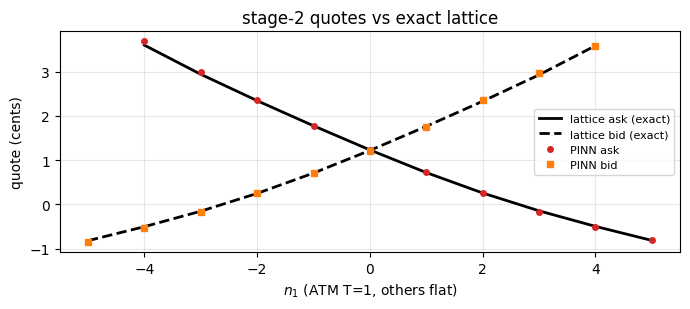

quote error vs exact: median 0.021c, max 0.085c


In [4]:
q_lat2 = lad2['quotes']                       # (2N, n_nu, M)
def pinn_quotes2(states):
    Np = states.shape[0]
    inst = np.concatenate([np.arange(N2), np.arange(N2)])
    psi = np.concatenate([np.ones(N2), -np.ones(N2)])
    shifts = jnp.asarray(-psi[:, None] * np.eye(N2)[inst])
    v0 = jax.vmap(lambda m: value(params2, spec2, 0.0, BBG_MARKET.nu0, m))(states)
    vsh = jax.vmap(lambda m: jax.vmap(lambda s: value(
        params2, spec2, 0.0, BBG_MARKET.nu0, m + s))(shifts))(states)
    p = (v0[:, None] - vsh) / ch2.z[None, :]
    d = _bc(ch2.intensity, 1).argmax_delta(p.T, -5.0)
    tgt = states[:, None, :] + shifts[None]
    adm = jnp.all(jnp.abs(tgt) <= nb2[None, None, :] + 1e-9, axis=-1)
    return np.asarray(jnp.where(adm.T, d, jnp.nan))

axis_states = np.zeros((2 * NBAR2[0] + 1, N2)); axis_states[:, 0] = np.arange(-NBAR2[0], NBAR2[0] + 1)
qp = pinn_quotes2(jnp.asarray(axis_states))
idx_flat = [int(np.where((n_pts2 == a).all(axis=1))[0][0]) for a in axis_states]
fig, ax = plt.subplots(figsize=(7, 3.2))
ns_ax = axis_states[:, 0]
ax.plot(ns_ax, 1e2 * q_lat2[0, i_nu2, idx_flat], 'k-', lw=2, label='lattice ask (exact)')
ax.plot(ns_ax, 1e2 * q_lat2[N2, i_nu2, idx_flat], 'k--', lw=2, label='lattice bid (exact)')
ax.plot(ns_ax, 1e2 * qp[0], 'o', c='tab:red', ms=4, label='PINN ask')
ax.plot(ns_ax, 1e2 * qp[N2], 's', c='tab:orange', ms=4, label='PINN bid')
ax.set_xlabel('$n_1$ (ATM T=1, others flat)'); ax.set_ylabel('quote (cents)')
ax.set_title('stage-2 quotes vs exact lattice'); ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()
qe = 1e2 * np.abs(np.concatenate([(qp[0] - q_lat2[0, i_nu2, idx_flat]),
                                  (qp[N2] - q_lat2[N2, i_nu2, idx_flat])]))
print(f'quote error vs exact: median {np.nanmedian(qe):.3f}c, max {np.nanmax(qe):.3f}c')

## 3. Stage 3 — the frontier

Universe: three vanilla calls ($K=9,10,11$, $T=1$) plus a **tight call
spread** (long 9.75 / short 10.25) whose vega flips sign inside the sampled
$S$ band.  Greeks are live $\mathcal{V}_i(S,\nu)$ from a COS-priced grid
surrogate (frozen in $t$ over the short horizon — documented).  Box limits,
$S$ in the state, the $\rho\xi\nu S\,\partial^2_{S\nu}$ cross term
live, horizon $T=0.006$ yr so $S$ actually moves through the flip
region.

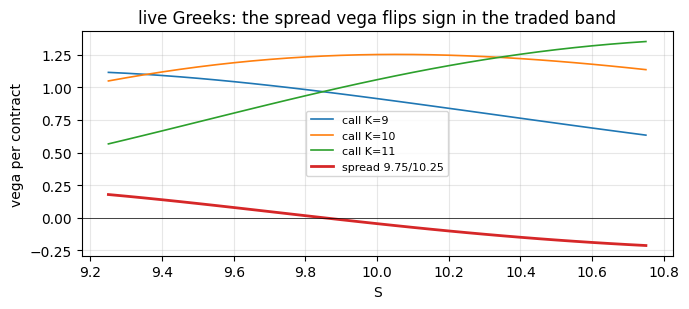

In [5]:
from optmm.instruments.surrogate import VegaGrid, build_stage3_book
from optmm.solvers.pinn.model3 import Pinn3Spec, init_params3, value3
from optmm.solvers.pinn.residual import residual_stage3
from optmm.sim.stage3 import simulate_stage3

T3 = 0.006
fb = CKPT / 'stage3_book.npz'
if fb.exists():
    b3 = dict(np.load(fb))
    vega_fn = VegaGrid(S_grid=jnp.asarray(b3['S_grid']),
                       nu_grid=jnp.asarray(b3['nu_grid']),
                       vega_tab=jnp.asarray(b3['vega_tab']))
    book3 = FrozenBook(K=jnp.asarray(b3['K']), tau=jnp.asarray(b3['tau']),
                       O0=jnp.asarray(b3['O0']), vega=jnp.asarray(b3['vega0']),
                       delta=jnp.zeros(4), z=jnp.asarray(b3['z']),
                       w=jnp.asarray(b3['w']), lam=jnp.asarray(b3['lam']),
                       alpha=jnp.full(4, 0.7), k=jnp.asarray(b3['k']))
else:
    book3, vega_fn, vref = build_stage3_book(BBG_MARKET)
ch3 = Channels.from_book(book3)

Ss = np.linspace(9.25, 10.75, 61)
V = np.stack([np.asarray(jax.vmap(lambda s: vega_fn(0., s, BBG_MARKET.nu0))(
    jnp.asarray(Ss)))[:, i] for i in range(4)])
fig, ax = plt.subplots(figsize=(7, 3.2))
labels = ['call K=9', 'call K=10', 'call K=11', 'spread 9.75/10.25']
for i in range(4):
    ax.plot(Ss, V[i], lw=2 if i == 3 else 1.2, label=labels[i])
ax.axhline(0, c='k', lw=.5); ax.set_xlabel('S'); ax.set_ylabel('vega per contract')
ax.set_title('live Greeks: the spread vega flips sign in the traded band')
ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

### 3a. Frozen-Greeks regression: the machinery must not invent $S$-dependence

Same $S$-featured network and stage-3 residual assembly, but with Greeks
pinned to their $(S_0,\nu_0)$ values and the vega slab — a problem whose
exact answer is the 2D reduction (signed per-trade vegas: the frozen spread
vega is negative).  Two things must emerge without being imposed: the value
matches the 2D reference, and $\partial_S v_\theta \approx 0$.

resumed frozen-regression checkpoint; topping up 300


  adam     0: loss 1.8211e+13 (rms 4.267e+06)


  adam   100: loss 5.3671e+12 (rms 2.317e+06)


  adam   200: loss 5.1535e+12 (rms 2.270e+06)


  adam   299: loss 8.0819e+12 (rms 2.843e+06)


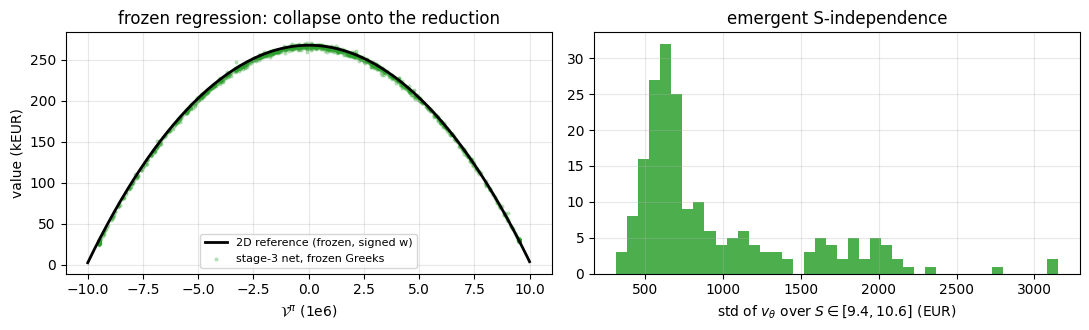

frozen regression: median |err| 1,555 EUR (center 267,574); median S-band std 717 EUR


In [6]:
from optmm.solvers.pinn.train import adam_train as _adam
refF = dict(np.load(CKPT / 'stage3_frozen_ref.npz'))
w_frozen = jnp.asarray(refF['w_frozen'])
bookF = replace(book3, w=w_frozen)
chF = Channels.from_book(bookF)
N_MAXF = jnp.array([12., 9., 4., 12.])
spec3F = Pinn3Spec(T=T3, S0=10.0, S_half=0.6, nu_lo=0.0144, nu_hi=0.0324,
                   w_ref=w_frozen, n_max=N_MAXF, Vbar=1e7,
                   hidden=PROFILE['hidden'])
pen = penalty_coef(GAMMA, BBG_MARKET.xi, BBG_MARKET.rho, 0.0)
frozen_greeks = lambda t, S, nu: book3.vega
resF = partial(residual_stage3, spec=spec3F, value_fn=value3, ch=chF,
               market=BBG_MARKET, pen=pen, Vbar=1e7, greeks=frozen_greeks,
               z_contracts=book3.z, adm_set=Slab(1e7))
lossF = lambda p, t, S, nu, n: jnp.mean(jax.vmap(
    lambda a, b_, c_, m: resF(p, t=a, S=b_, nu=c_, n=m))(t, S, nu, n) ** 2)

def samplerF(key, spec, batch):
    k1, k2, k3, k4, k5 = jax.random.split(key, 5)
    t = jax.random.uniform(k1, (batch,)) * spec.T
    S = spec.S0 + spec.S_half * jax.random.uniform(k2, (batch,), minval=-1., maxval=1.)
    pad = 0.2 * (spec.nu_hi - spec.nu_lo)
    nu = jax.random.uniform(k3, (batch,)) * (spec.nu_hi - spec.nu_lo + 2 * pad) \
        + spec.nu_lo - pad
    n = jax.random.uniform(k4, (batch, 4), minval=-1., maxval=1.) * spec.n_max[None, :]
    n = n * jax.random.uniform(k5, (batch, 1)) ** 0.5
    Vpi = n @ spec.w_ref
    return t, S, nu, n * jnp.minimum(1.0, .95e7 / (jnp.abs(Vpi) + 1e-30))[:, None]

ckF = CKPT / 'pinn_stage3_frozen.pkl'
if ckF.exists():
    with open(ckF, 'rb') as fh: sF = pickle.load(fh)
    paramsF = jax.tree_util.tree_map(jnp.asarray, sF['params'])
    stepsF = PROFILE['topup_steps']
    print(f'resumed frozen-regression checkpoint; topping up {stepsF}')
else:
    paramsF = init_params3(spec3F, jax.random.PRNGKey(0))
    stepsF = PROFILE['fresh_steps']
paramsF, _ = _adam(paramsF, lossF, spec3F, jax.random.PRNGKey(1), steps=stepsF,
                   batch=PROFILE['batch'], lr=PROFILE['lr'],
                   log_every=max(stepsF // 3, 1), sampler=samplerF)
with open(ckF, 'wb') as fh:
    pickle.dump({'params': jax.tree_util.tree_map(np.asarray, paramsF),
                 'hidden': tuple(PROFILE['hidden'])}, fh)

_, _, _, n_sF = samplerF(jax.random.PRNGKey(9), spec3F, 1500)
vpF = np.asarray(jax.vmap(lambda n: value3(paramsF, spec3F, 0.0, 10.0, 0.0225,
                                           n))(n_sF))
VpiF = np.asarray(n_sF @ w_frozen)
v2F = np.interp(VpiF, refF['V_grid'], refF['v_row'])
SsF = jnp.linspace(9.4, 10.6, 9)
vSF = np.asarray(jax.vmap(lambda s: jax.vmap(lambda n: value3(
    paramsF, spec3F, 0.0, s, 0.0225, n))(n_sF[:200]))(SsF))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
o = np.argsort(VpiF)
axes[0].plot(refF['V_grid'] / 1e6, refF['v_row'] / 1e3, 'k-', lw=2,
             label='2D reference (frozen, signed w)')
axes[0].scatter(VpiF / 1e6, vpF / 1e3, s=4, alpha=.25, c='tab:green',
                label='stage-3 net, frozen Greeks')
axes[0].set_xlabel(r'$\mathcal{V}^\pi$ (1e6)'); axes[0].set_ylabel('value (kEUR)')
axes[0].legend(fontsize=8); axes[0].grid(alpha=.3)
axes[0].set_title('frozen regression: collapse onto the reduction')
axes[1].hist(np.std(vSF, axis=0), bins=40, color='tab:green', alpha=.85)
axes[1].set_xlabel('std of $v_\\theta$ over $S \\in [9.4, 10.6]$ (EUR)')
axes[1].set_title('emergent S-independence'); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()
print(f'frozen regression: median |err| {np.median(np.abs(vpF - v2F)):,.0f} EUR '
      f'(center {float(np.interp(0, refF["V_grid"], refF["v_row"])):,.0f}); '
      f'median S-band std {np.median(np.std(vSF, axis=0)):,.0f} EUR')

### 3b. Live stage 3: training, the policy through the sign flip

With live Greeks and the box: train, then look at what the desk consumes —
the spread's quotes as $S$ crosses the flip.  Below the flip the spread is
long-vega (buying it adds vega); above, the roles of bid and ask reverse.
The skew response through the flip is the policy-level signature that the
network is using state-dependent risk, not the frozen anchor.

resumed live checkpoint; topping up 300


  adam     0: loss 2.2888e+14 (rms 1.513e+07)


  adam   100: loss 9.0168e+13 (rms 9.496e+06)


  adam   200: loss 8.5920e+13 (rms 9.269e+06)


  adam   299: loss 1.7777e+14 (rms 1.333e+07)


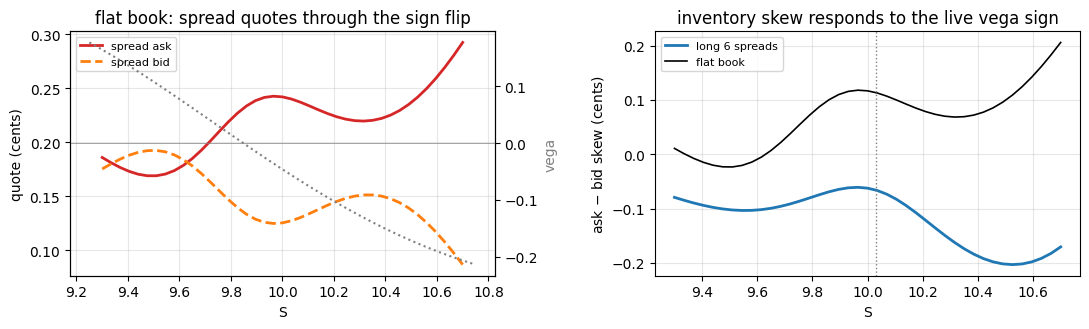

In [7]:
NBAR3 = np.array([4, 4, 4, 8]); box3 = Box(NBAR3)
spec3 = Pinn3Spec(T=T3, S0=10.0, S_half=0.6, nu_lo=0.0144, nu_hi=0.0324,
                  w_ref=book3.z * book3.vega,
                  n_max=jnp.asarray(NBAR3, jnp.float64), Vbar=1e7,
                  hidden=PROFILE['hidden'])
resL = partial(residual_stage3, spec=spec3, value_fn=value3, ch=ch3,
               market=BBG_MARKET, pen=pen, Vbar=1e7, greeks=vega_fn,
               z_contracts=book3.z, adm_set=box3)
lossL = lambda p, t, S, nu, n: jnp.mean(jax.vmap(
    lambda a, b_, c_, m: resL(p, t=a, S=b_, nu=c_, n=m))(t, S, nu, n) ** 2)
nb3 = jnp.asarray(NBAR3, jnp.float64)
def samplerL(key, spec, batch):
    k1, k2, k3, k4 = jax.random.split(key, 4)
    t = jax.random.uniform(k1, (batch,)) * spec.T
    S = spec.S0 + spec.S_half * jax.random.uniform(k2, (batch,), minval=-1., maxval=1.)
    pad = 0.2 * (spec.nu_hi - spec.nu_lo)
    nu = jax.random.uniform(k3, (batch,)) * (spec.nu_hi - spec.nu_lo + 2 * pad) \
        + spec.nu_lo - pad
    n = jax.random.uniform(k4, (batch, 4), minval=-1., maxval=1.) * nb3[None, :]
    return t, S, nu, n

ckL = CKPT / 'pinn_stage3_live.pkl'
if ckL.exists():
    with open(ckL, 'rb') as fh: sL = pickle.load(fh)
    paramsL = jax.tree_util.tree_map(jnp.asarray, sL['params'])
    lhL = list(sL.get('loss_hist', []))
    stepsL = PROFILE['topup_steps']
    print(f'resumed live checkpoint; topping up {stepsL}')
else:
    paramsL = init_params3(spec3, jax.random.PRNGKey(0)); lhL = []
    stepsL = PROFILE['fresh_steps']
paramsL, hL = _adam(paramsL, lossL, spec3, jax.random.PRNGKey(1), steps=stepsL,
                    batch=PROFILE['batch'], lr=PROFILE['lr'],
                    log_every=max(stepsL // 3, 1), sampler=samplerL)
off = lhL[-1][0] + 1 if lhL else 0
lhL += [(off + i, l) for i, l in hL]

Sq = np.linspace(9.3, 10.7, 41)
psi3 = np.concatenate([np.ones(4), -np.ones(4)])
shifts3 = jnp.asarray(-psi3[:, None] * np.eye(4)[np.concatenate([np.arange(4)] * 2)])
def quotes_vs_S(params, n0):
    def one(s):
        v0 = value3(params, spec3, 0.0, s, BBG_MARKET.nu0, n0)
        vs = jax.vmap(lambda sh: value3(params, spec3, 0.0, s, BBG_MARKET.nu0,
                                        n0 + sh))(shifts3)
        p = (v0 - vs) / ch3.z
        return _bc(ch3.intensity, 0).argmax_delta(p, -5.0)
    return np.asarray(jax.vmap(one)(jnp.asarray(Sq)))
qS = quotes_vs_S(paramsL, jnp.zeros(4))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(Sq, 1e2 * qS[:, 3], '-', c='tab:red', lw=2, label='spread ask')
axes[0].plot(Sq, 1e2 * qS[:, 7], '--', c='tab:orange', lw=2, label='spread bid')
ax2 = axes[0].twinx()
ax2.plot(Ss, V[3], ':', c='gray', label='spread vega (right)')
ax2.axhline(0, c='gray', lw=.5); ax2.set_ylabel('vega', color='gray')
axes[0].set_xlabel('S'); axes[0].set_ylabel('quote (cents)')
axes[0].set_title('flat book: spread quotes through the sign flip')
axes[0].legend(fontsize=8, loc='upper left'); axes[0].grid(alpha=.3)
skew = qS[:, 3] - qS[:, 7]
n_long = jnp.array([0., 0., 0., 6.])       # long 6 spreads
qL = quotes_vs_S(paramsL, n_long)
axes[1].plot(Sq, 1e2 * (qL[:, 3] - qL[:, 7]), lw=2, c='tab:blue',
             label='long 6 spreads')
axes[1].plot(Sq, 1e2 * skew, lw=1.2, c='k', label='flat book')
axes[1].axvline(10.03, c='gray', ls=':', lw=1)
axes[1].set_xlabel('S'); axes[1].set_ylabel('ask $-$ bid skew (cents)')
axes[1].set_title('inventory skew responds to the live vega sign')
axes[1].legend(fontsize=8); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

### 3c. Dynkin closure — the no-reference validation

Greedy-from-$v_\theta$ policy attains the Hamiltonian sup, so the linear
residual equals the HJB residual and

$$\mathbb{E}\Big[\textstyle\sum \text{reward}\Big]
  \;=\; v_\theta(0,x_0) \;+\;
  \mathbb{E}\Big[\int_0^T R_\theta(t,S_t,\nu_t,n_t)\,dt\Big].$$

Both sides estimated on the same CRN paths.  This machinery was
pre-validated against exact references at stage 1
(`tests/test_corrector.py`); here it is the primary instrument.  A residual
pool + ascent gives the certificate-style companion number.

In [8]:
t0 = time.time()
sim3 = simulate_stage3(paramsL, spec3, ch3, vega_fn, book3.z, BBG_MARKET,
                       GAMMA, box3, T3, n_steps=1200,
                       n_paths=PROFILE['closure_paths'], res_stride=4, seed=5)
sim3.reward.block_until_ready()
r3, c3 = np.asarray(sim3.reward), np.asarray(sim3.corr)
v03 = float(value3(paramsL, spec3, 0.0, 10.0, 0.0225, jnp.zeros(4)))
lhs, lse = r3.mean(), r3.std() / np.sqrt(len(r3))
rhs = v03 + c3.mean()
gse = np.std(r3 - c3) / np.sqrt(len(r3))
print(f'closure sim ({len(r3)} paths x 1200 steps, {time.time()-t0:.0f}s)')
print(f'  E[reward]          = {lhs:>12,.0f} +/- {lse:,.0f}')
print(f'  v_theta(0)         = {v03:>12,.0f}')
print(f'  E[int R dt]        = {c3.mean():>12,.0f}   (Dynkin correction)')
print(f'  v_theta + E[int R] = {rhs:>12,.0f}')
print(f'  closure gap        = {lhs-rhs:>+12,.0f} EUR = {(lhs-rhs)/gse:+.2f} SE (CRN paired)')
print(f'  fills/path {np.asarray(sim3.fills).mean():.1f} | '
      f'rms live Vpi {np.asarray(sim3.Vpi_path_rms).mean()/1e6:.2f}e6')
with open(ckL, 'wb') as fh:
    pickle.dump({'params': jax.tree_util.tree_map(np.asarray, paramsL),
                 'hidden': tuple(PROFILE['hidden']), 'nbar': NBAR3,
                 'loss_hist': lhL,
                 'closure': {'sim': float(lhs), 'sim_se': float(lse),
                             'v0': v03, 'corr': float(c3.mean()),
                             'gap': float(lhs - rhs), 'gap_se': float(gse)}},
                fh)

# residual pool + light adversarial ascent (certificate-style companion)
tP, SP, nuP, nP = samplerL(jax.random.PRNGKey(11), spec3, 3000)
RP = np.asarray(jax.vmap(lambda a, b_, c_, m: resL(paramsL, t=a, S=b_, nu=c_,
                                                   n=m))(tP, SP, nuP, nP))
worst = np.argsort(-np.abs(RP))[:12]
gfun = jax.jit(jax.grad(lambda t, S, nu, n: resL(paramsL, t=t, S=S, nu=nu,
                                                 n=n) ** 2, argnums=(0, 1, 2, 3)))
ta, Sa, na_, ma = tP[worst], SP[worst], nuP[worst], nP[worst]
for _ in range(20):
    gt, gS, gn, gm = jax.vmap(gfun)(ta, Sa, na_, ma)
    sc = 1.0 / (jnp.abs(jax.vmap(lambda a, b_, c_, m: resL(
        paramsL, t=a, S=b_, nu=c_, n=m))(ta, Sa, na_, ma)) + 1e-9)
    ta = jnp.clip(ta + 1e-9 * sc * gt, 0.0, T3)
    Sa = jnp.clip(Sa + 1e-4 * sc * gS, 9.4, 10.6)
    na_ = jnp.clip(na_ + 1e-7 * sc * gn, spec3.nu_lo, spec3.nu_hi)
    ma = jnp.clip(ma + 3e-2 * sc[:, None] * gm
                  / (jnp.linalg.norm(gm, axis=1, keepdims=True) + 1e-30),
                  -nb3[None, :], nb3[None, :])
R_adv = np.asarray(jax.vmap(lambda a, b_, c_, m: resL(paramsL, t=a, S=b_,
                                                      nu=c_, n=m))(ta, Sa, na_, ma))
print(f'\nresidual pool: median {np.median(np.abs(RP)):.2e}, '
      f'max {np.max(np.abs(RP)):.2e} EUR/yr; ascent -> {np.max(np.abs(R_adv)):.2e} '
      f'(x{np.max(np.abs(R_adv))/np.max(np.abs(RP)):.2f})')

closure sim (800 paths x 1200 steps, 12s)
  E[reward]          =      263,690 +/- 2,585
  v_theta(0)         =      265,111
  E[int R dt]        =       -3,568   (Dynkin correction)
  v_theta + E[int R] =      261,543
  closure gap        =       +2,147 EUR = +0.83 SE (CRN paired)
  fills/path 34.2 | rms live Vpi 1.33e6



residual pool: median 4.46e+06, max 7.29e+08 EUR/yr; ascent -> 1.14e+09 (x1.57)


## 4. Verdict

The three-step arc is complete at smoke scale, each stage validated by the
strongest instrument available to it: stage 1 by the exact reduction (and
its own atom-exact refinement), stage 2 by the exact lattice on every
admissible state — with the ladder table putting honest numbers on the
cardinality curse the PINN must eventually beat — and stage 3, where
nothing exact exists, by the frozen-Greeks regression (value collapse plus
*emergent* S-independence), the policy-level sign-flip response, and the
Dynkin closure on CRN paths, itself pre-validated at stage 1.

Caveats, unchanged in spirit: all trainings here are CPU smoke budgets
(re-run on CUDA for the full budgets, including the still-unexercised GN-CG
polish); the residual-pool ascent is a preview, not a certificate; the
stage-3 Greeks are frozen in $t$ over the short horizon and the Dynkin
integral is strided-Riemann (bias $O(\text{stride}\cdot dt)$); and the
per-dim input normalizations use public book/constraint data — documented
in the stage-1 notebook's discovery caveat.